# Random Subspace Method — mtcars  
Diego Dueñas Martín  
751426  

**Target:**  | **Split:** 50/50 | **Iteraciones:** 1000 | **Vars por modelo:** 3

In [64]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from collections import Counter

df = pd.read_excel("Motor Trend Car Road Tests.xlsx")

TARGET   = "mpg"
FEATURES = [c for c in df.columns if c not in ("model", TARGET)]
# ['cyl','disp','hp','drat','wt','qsec','vs','am','gear','carb']

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (16, 10)  |  Test: (16, 10)


---
## SECCIÓN 1 — BOOTSTRAPPING
Para cada iteración : elegir 3 vars al azar (sin reemplazo dentro de la iteración), entrenar OLS sobre train, predecir sobre test.

In [65]:
np.random.seed(42)

N_ITER = 1000
N_VARS = 3

results = []

for i in range(N_ITER):

    # Vars_i → 3 variables sin reemplazo dentro de la iteración
    vars_i    = np.random.choice(FEATURES, size=N_VARS, replace=False).tolist()

    X_train_i = sm.add_constant(X_train[vars_i])
    X_test_i  = sm.add_constant(X_test[vars_i])

    # Entrenar
    model_i   = sm.OLS(y_train, X_train_i).fit()

    # Predecir
    y_hat_i   = model_i.predict(X_test_i)

    results.append({
        "iter"    : i,
        "vars"    : vars_i,
        "coefs"   : model_i.params.to_dict(),
        "r2_train": model_i.rsquared,
        "y_hat"   : y_hat_i.values,
    })

print(f"{N_ITER} modelos entrenados correctamente.")

# Mostrar resultados
r2_scores = [r["r2_train"] for r in results]
print(f"\nR2 Entrenamiento:")
print(f"  Mínimo:  {np.min(r2_scores):.4f}")
print(f"  Máximo:  {np.max(r2_scores):.4f}")
print(f"  Promedio: {np.mean(r2_scores):.4f}")
print(f"  Desv. Est: {np.std(r2_scores):.4f}")

# Mostrar primeros N modelos
print(f"\nPrimeros 3 modelos:")
for i in range(3):
    print(f"  Iter {i}: vars={results[i]['vars']}, R2={results[i]['r2_train']:.4f}")

1000 modelos entrenados correctamente.

R2 Entrenamiento:
  Mínimo:  0.4718
  Máximo:  0.9028
  Promedio: 0.7853
  Desv. Est: 0.0676

Primeros 3 modelos:
  Iter 0: vars=['gear', 'disp', 'qsec'], R2=0.7830
  Iter 1: vars=['cyl', 'disp', 'gear'], R2=0.7865
  Iter 2: vars=['carb', 'hp', 'cyl'], R2=0.7304


---
## SECCIÓN 2 — AGGREGATING
Consolidar los 1000 modelos: tabla de coeficientes y matriz de predicciones.

In [66]:
# Coeficientes → una fila por iteración
coef_rows = []
for r in results:
    row = {"iter": r["iter"], "vars": str(r["vars"]), "r2_train": r["r2_train"]}
    row.update(r["coefs"])
    coef_rows.append(row)

df_coefs = pd.DataFrame(coef_rows)

# Predicciones → columnas = iteraciones, filas = obs de test
y_hat_matrix = np.vstack([r["y_hat"] for r in results]).T   # (n_test, 1000)
df_preds = pd.DataFrame(
    y_hat_matrix,
    index   = X_test.index,
    columns = [f"iter_{i}" for i in range(N_ITER)],
)
df_preds.insert(0, "y_real", y_test.values)

df_coefs.to_csv("rs_coeficientes.csv", index=False)
df_preds.to_csv("rs_predicciones.csv", index=True)

print(f"df_coefs : {df_coefs.shape}")
print(f"df_preds : {df_preds.shape}")
print(f"R² promedio train : {df_coefs['r2_train'].mean():.4f}")
df_coefs.head()

df_coefs : (1000, 14)
df_preds : (16, 1001)
R² promedio train : 0.7853


,iter,vars,r2_train,const,gear,disp,qsec,cyl,carb,hp,am,vs,wt,drat
0,0,"['gear', 'disp', 'qsec']",0.782971,13.583268,1.856588,-0.038067,0.471210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"['cyl', 'disp', 'gear']",0.786464,28.291528,1.142514,-0.031039,NaN,-0.881373,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"['carb', 'hp', 'cyl']",0.730439,37.845570,NaN,NaN,NaN,-2.365793,-0.33592,-0.018461,NaN,NaN,NaN,NaN
3,3,"['disp', 'am', 'vs']",0.795532,25.809900,NaN,-0.034205,NaN,NaN,NaN,NaN,2.95291,1.859691,NaN,NaN
4,4,"['disp', 'qsec', 'wt']",0.877413,17.036365,NaN,0.004497,1.237503,NaN,NaN,NaN,NaN,NaN,-6.48057,NaN


In [67]:
freq = Counter(v for r in results for v in r["vars"])
print("Frecuencia de selección (de 3000 slots totales):")
for var, cnt in sorted(freq.items(), key=lambda x: -x[1]):
    print(f"  {var:6s}  {cnt:4d}  ({cnt/N_ITER*100/N_VARS:.1f} %)")

Frecuencia de selección (de 3000 slots totales):
  gear     332  (11.1 %)
  hp       316  (10.5 %)
  am       311  (10.4 %)
  wt       302  (10.1 %)
  cyl      301  (10.0 %)
  qsec     299  (10.0 %)
  carb     295  (9.8 %)
  disp     294  (9.8 %)
  drat     277  (9.2 %)
  vs       273  (9.1 %)


---
## SECCIÓN 3 — RANDOM FOREST
Optimización de hiperparámetros con K-Fold CV (k=5) para maximizar R2 en test.

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators"     : [103,104,105,106,107],
    "max_depth"        : [3,4,5,6,7],
    "max_leaf_nodes"   : [12,13,14,15,16],
}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator           = rf,
    param_distributions = param_dist,
    n_iter              = 30,          # 30 combinaciones aleatorias
    cv                  = 5,           # K-Fold con k=5
    scoring             = "r2",
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)

print("Optimizando Random Forest (30 combinaciones, CV k=5)...")
search.fit(X_train, y_train)

print(f"\nMejor R2 en CV: {search.best_score_:.4f}")
print("Mejores parámetros:")
for k, v in search.best_params_.items():
    print(f"  {k:20s} : {v}")

Optimizando Random Forest (30 combinaciones, CV k=5)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejor R2 en CV: 0.7568
Mejores parámetros:
  n_estimators         : 105
  max_leaf_nodes       : 15
  max_depth            : 5


In [69]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

best_rf = search.best_estimator_

# Predicciones
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf  = best_rf.predict(X_test)

# Métricas
r2_train_rf  = r2_score(y_train, y_train_pred_rf)
r2_test_rf   = r2_score(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_test_rf  = mean_absolute_error(y_test, y_test_pred_rf)

print(f"R² train       : {r2_train_rf:.4f}")
print(f"R² test        : {r2_test_rf:.4f}")
print(f"RMSE test      : {rmse_test_rf:.4f} mpg")
print(f"MAE test       : {mae_test_rf:.4f} mpg")

R² train       : 0.9682
R² test        : 0.8403
RMSE test      : 2.0783 mpg
MAE test       : 1.6254 mpg



Importancia de features:
feature  importance
     wt    0.325982
     hp    0.290091
   disp    0.183576
    cyl    0.078813
   drat    0.033947
   qsec    0.027937
   carb    0.023191
     vs    0.015147
   gear    0.013685
     am    0.007631


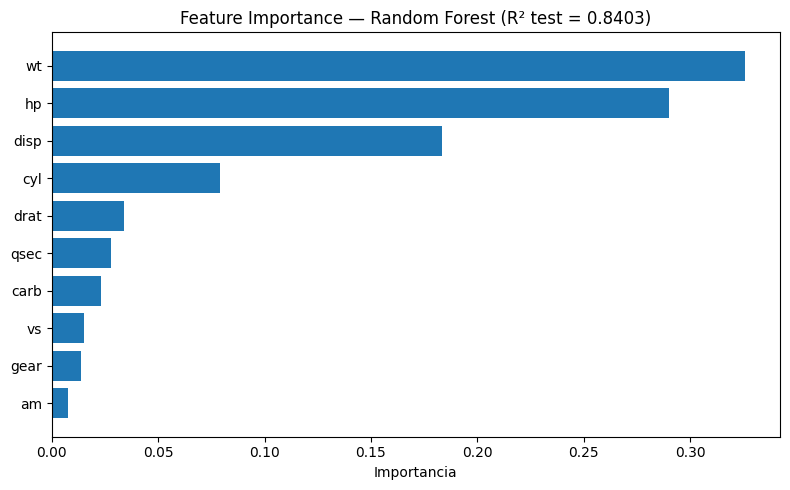

In [70]:
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    "feature"    : FEATURES,
    "importance" : best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportancia de features:")
print(importances.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importances["feature"], importances["importance"])
plt.xlabel("Importancia")
plt.title(f"Feature Importance — Random Forest (R² test = {r2_test_rf:.4f})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [71]:
# Comparación con Random Subspace
y_hat_mean_rs = df_preds[[f"iter_{i}" for i in range(N_ITER)]].mean(axis=1)
r2_test_rs = r2_score(y_test, y_hat_mean_rs)

print("\n" + "="*60)
print("COMPARACIÓN: Random Subspace vs Random Forest")
print("="*60)
print(f"Random Subspace (promedio de 1000 modelos):  R² test = {r2_test_rs:.4f}")
print(f"Random Forest (optimizado):                  R² test = {r2_test_rf:.4f}")
print(f"Diferencia:                                           {r2_test_rf - r2_test_rs:+.4f}")
print("="*60)


COMPARACIÓN: Random Subspace vs Random Forest
Random Subspace (promedio de 1000 modelos):  R² test = 0.7817
Random Forest (optimizado):                  R² test = 0.8403
Diferencia:                                           +0.0586


---
## SECCIÓN 4 — Boosting

In [72]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

param_dist_gb = {
    "n_estimators"   : [104, 105, 106, 107,108],
    "max_depth"      : [1,2,3, 4, 5],
    "max_leaf_nodes" : [12, 13, 14, 15, 16],
}

gb = GradientBoostingRegressor(random_state=42)

search_gb = RandomizedSearchCV(
    estimator           = gb,
    param_distributions = param_dist_gb,
    n_iter              = 25,
    cv                  = 10,  
    scoring             = "r2",
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)

print("Optimizando Boosting (10-fold CV)...")
search_gb.fit(X_train, y_train)

print(f"\nMejor R2 en CV: {search_gb.best_score_:.4f}")
print("Mejores parámetros Boosting:")
for k, v in search_gb.best_params_.items():
    print(f"  {k:20s} : {v}")

best_gb = search_gb.best_estimator_

# Scores de cada fold para el mejor modelo
scores_gb = cross_val_score(best_gb, X_train, y_train, cv=10, scoring='r2')
print(f"\nScores de cada fold: {scores_gb}")
print(f"Promedio de folds: {scores_gb.mean():.4f}")

y_train_pred_gb = best_gb.predict(X_train)
y_test_pred_gb  = best_gb.predict(X_test)

r2_train_gb  = r2_score(y_train, y_train_pred_gb)
r2_test_gb   = r2_score(y_test, y_test_pred_gb)
rmse_test_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
mae_test_gb  = mean_absolute_error(y_test, y_test_pred_gb)

print(f"\nBoosting resultados:")
print(f"R² train       : {r2_train_gb:.4f}")
print(f"R² test        : {r2_test_gb:.4f}")
print(f"RMSE test      : {rmse_test_gb:.4f} mpg")
print(f"MAE test       : {mae_test_gb:.4f} mpg")

print("\nComparación con Random Forest optimizado:")
print(f"  R² test Boosting     = {r2_test_gb:.4f}")
print(f"  R² test RandomForest = {r2_test_rf:.4f}")
print(f"  Diferencia           = {r2_test_gb - r2_test_rf:+.4f}")

Optimizando Boosting (10-fold CV)...
Fitting 10 folds for each of 25 candidates, totalling 250 fits


C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)



Mejor R2 en CV: nan
Mejores parámetros Boosting:
  n_estimators         : 107
  max_leaf_nodes       : 15
  max_depth            : 1

Scores de cada fold: [ 8.43884268e-01 -7.76223680e-01  6.41447132e-01  9.08386411e-01
 -1.72099731e+03  1.79901808e-01             nan             nan
             nan             nan]
Promedio de folds: nan

Boosting resultados:
R² train       : 0.9983
R² test        : 0.7632
RMSE test      : 2.5309 mpg
MAE test       : 1.9777 mpg

Comparación con Random Forest optimizado:
  R² test Boosting     = 0.7632
  R² test RandomForest = 0.8403
  Diferencia           = -0.0771


C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
